In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('cars24-car-price-cleaned-new.csv')
df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


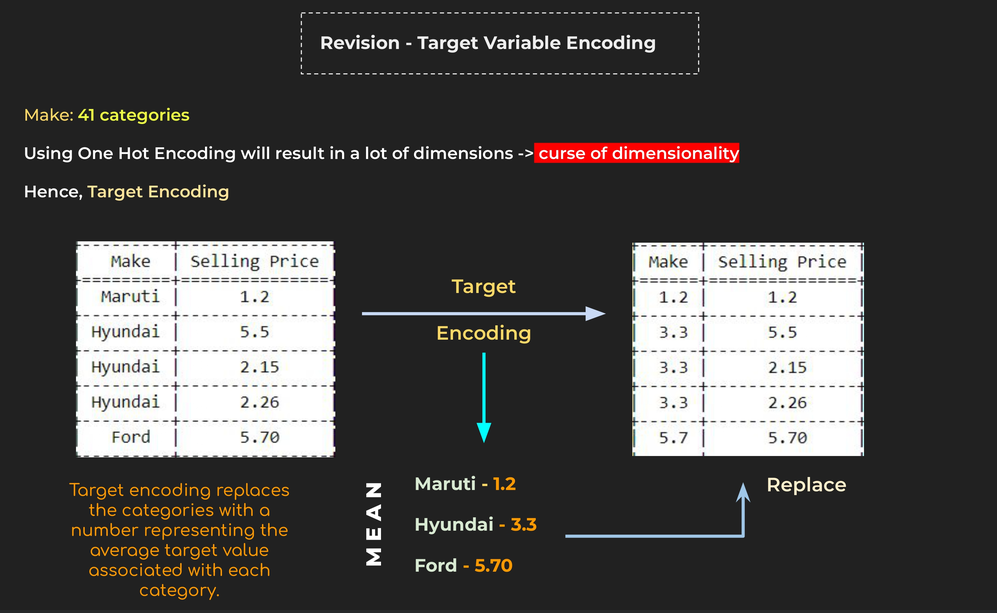

In [4]:
# And we are using the startegy of mean as the data is not skewed 
df["make"]=df.groupby("make")["selling_price"].transform("mean")
df["model"]=df.groupby("model")["selling_price"].transform("mean")

### Scaling the data

Notice one more thing:

- `km_driven` is in the ranges of 10000s,
- while `age` is in the range of 10s.

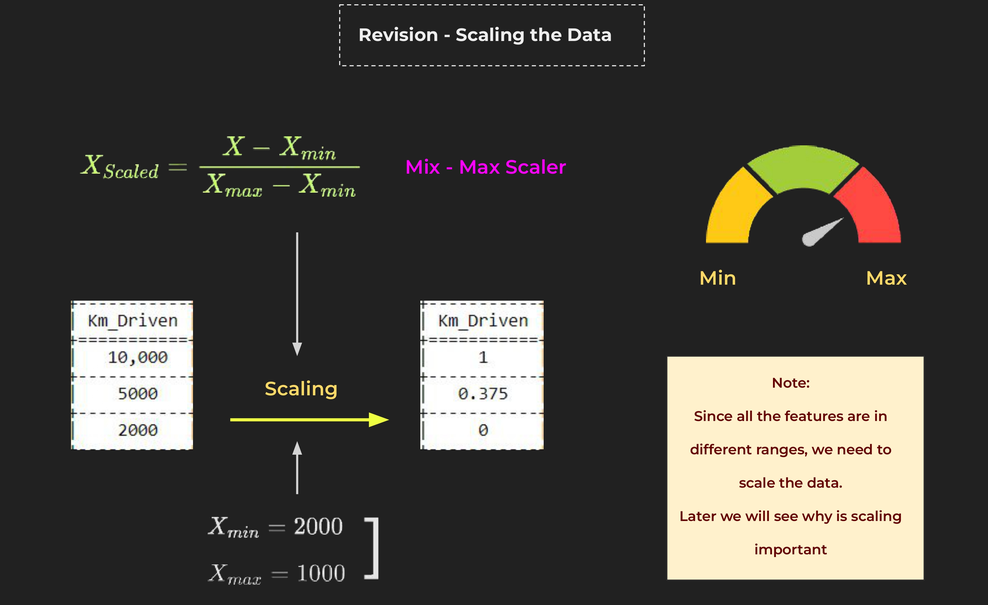

In [ ]:
%pip install scikit-learn


In [9]:
from sklearn.preprocessing import MinMaxScaler 
scaler=MinMaxScaler()
df=pd.DataFrame(scaler.fit_transform(df),columns=df.columns)
df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.043684,0.031553,0.135345,0.117891,0.066506,0.310345,0.194048,0.041550,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.252397,0.005237,0.128448,0.177281,0.123994,0.172414,0.232517,0.218382,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.089795,0.015764,0.112069,0.177281,0.120773,0.379310,0.232517,0.149143,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.095134,0.009711,0.145862,0.147808,0.100000,0.310345,0.194048,0.093193,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.262104,0.007869,0.161810,0.221860,0.150709,0.206897,0.252367,0.313574,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


# 📏 Feature Scaling — Making Features Comparable

---

# 🎯 What is Feature Scaling?

Feature Scaling is the process of transforming numerical features so that they are on a **similar scale**.

The purpose is **not to change the meaning of the data**, but to ensure that one feature does not dominate another simply because it has larger numerical values.

---

# 🤔 Why Do We Need Scaling?

Suppose we're building a machine learning model to predict house prices.

Our dataset looks like this:

| Age (Years) | Number of Rooms | Area (sq ft) |
| ----------- | --------------- | ------------ |
| 20          | 4               | 2500         |
| 25          | 3               | 3200         |
| 30          | 5               | 4000         |

Notice the scales:

```text
Age      → 20–30

Rooms    → 3–5

Area     → 2500–4000
```

Although **Area** is not necessarily the most important feature, its values are much larger.

Many machine learning algorithms will naturally give it more importance simply because of its larger magnitude.

This creates **bias**.

---

# 🎯 The Core Problem

Imagine calculating the distance between two houses.

House A

```text
Age = 20

Area = 2000
```

House B

```text
Age = 25

Area = 4000
```

Differences

```text
Age Difference    = 5

Area Difference   = 2000
```

Distance

[
\sqrt{5^2 + 2000^2}
]

Clearly,

```text
2000 >> 5
```

The distance is almost entirely determined by **Area**.

The **Age** feature contributes almost nothing.

---

# 💡 Real-Life Analogy

Imagine comparing two students using:

* Maths Marks
* Height

| Student | Maths | Height (cm) |
| ------- | ----- | ----------- |
| A       | 95    | 170         |
| B       | 90    | 175         |

Can we directly compare

```text
95

and

170
```

No.

They are measured in different units.

Similarly,

Machine Learning algorithms often assume that all features contribute fairly.

Scaling puts all features on a comparable scale.

---

# 📊 Before Scaling

| Feature | Value  |
| ------- | ------ |
| Age     | 25     |
| Salary  | 80,000 |

The algorithm mainly focuses on

```text
Salary
```

because

```text
80000 >> 25
```

---

# 📊 After Scaling

| Feature | Scaled Value |
| ------- | ------------ |
| Age     | 0.42         |
| Salary  | 0.51         |

Now both features contribute fairly.

---

# ⚠️ Does Scaling Change the Data?

**No.**

Scaling changes only the **numerical representation**, not the underlying relationships.

Example:

Original

```text
Age

20

25

30
```

Scaled

```text
-1

0

1
```

The order remains exactly the same.

Only the scale changes.

---

# 🚀 When is Scaling Required?

Scaling is important for algorithms that depend on:

* Distance
* Gradient Descent
* Dot Products
* Optimization

Examples include:

* ✅ K-Nearest Neighbors (KNN)
* ✅ K-Means Clustering
* ✅ Logistic Regression
* ✅ Linear Regression (Gradient Descent)
* ✅ Support Vector Machines (SVM)
* ✅ Neural Networks
* ✅ Principal Component Analysis (PCA)

---

# ❌ When is Scaling NOT Required?

Tree-based algorithms split data based on feature values.

They do not depend on feature magnitudes.

Examples:

* ❌ Decision Tree
* ❌ Random Forest
* ❌ XGBoost
* ❌ LightGBM
* ❌ CatBoost

These algorithms work perfectly even without scaling.

---

# 📏 Types of Feature Scaling

There are two techniques you'll use most often.

---

# 1️⃣ Min-Max Scaling (Normalization)

Min-Max Scaling transforms every value into the range

```text
0 → 1
```

Formula

\frac{x-x_{min}}
{x_{max}-x_{min}}
]

---

### Example

Original

```text
10

20

30
```

Minimum

```text
10
```

Maximum

```text
30
```

Scaled

```text
0

0.5

1
```

---

### Advantages

* Preserves the shape of the data.
* Values remain within a fixed range.
* Commonly used in image processing and neural networks.

---

### Disadvantages

Very sensitive to outliers.

Suppose one value becomes

```text
1000
```

Everything else gets compressed near zero.

---

# 💻 Min-Max Scaling in Python

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
```

---

# 2️⃣ Standardization (Z-Score Scaling)

This is the most commonly used scaling technique.

Formula

\frac{x-\mu}
{\sigma}
]

where

* μ = Mean
* σ = Standard Deviation

---

### After Standardization

Mean becomes approximately

```text
0
```

Standard Deviation becomes approximately

```text
1
```

---

### Example

Original

```text
20

25

30
```

Mean

```text
25
```

Standardized

```text
-1

0

1
```

---

### Advantages

* Works well for many machine learning algorithms.
* Less affected by outliers than Min-Max Scaling.
* Most widely used in practice.

---

# 💻 Standardization in Python

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
```

---

# ⚙️ What Does `fit_transform()` Do?

It performs two operations.

---

## Step 1 — `fit()`

Learn the statistics from the training data.

For StandardScaler

```text
Compute Mean

Compute Standard Deviation
```

For MinMaxScaler

```text
Compute Minimum

Compute Maximum
```

---

## Step 2 — `transform()`

Use those learned statistics to scale the data.

---

# 🚨 Why Should We Never Fit on Test Data?

Suppose

Training salaries

```text
20k

30k

40k
```

Test salaries

```text
100k

120k
```

If we fit on the test data,

the model gains information about unseen data.

This is called

> **Data Leakage**

It leads to overly optimistic evaluation results.

---

#

---

# 📊 StandardScaler vs MinMaxScaler

| StandardScaler               | MinMaxScaler                              |
| ---------------------------- | ----------------------------------------- |
| Mean becomes 0               | Values between 0 and 1                    |
| Standard deviation becomes 1 | Uses minimum and maximum values           |
| Less sensitive to outliers   | Highly sensitive to outliers              |
| Most commonly used           | Common for image data and neural networks |

---

#

---

# 📌 Key Takeaways

* Feature Scaling puts numerical features on a comparable scale.
* Scaling prevents large-valued features from dominating smaller-valued ones.
* Scaling is essential for distance-based and gradient-based algorithms.
* Tree-based algorithms generally do not require scaling.
* The two most common techniques are:

  * **Min-Max Scaling**
  * **Standardization (Z-Score Scaling)**
* Always **fit the scaler only on the training data** and use the same scaler to transform the test data.

---

# 🚀 One-Line Summary

> **Feature Scaling transforms numerical features to a common scale so that every feature contributes fairly during model training, improving convergence, stability, and overall model performance.**

---

# ⭐ Ultimate Intuition

> **Without Scaling:**
> "Large numbers dominate the learning process."

> **With Scaling:**
> "Every feature gets a fair chance to contribute, regardless of its original units or magnitude."

Feature scaling doesn't make the data **better**—it makes the data **fair** for machine learning algorithms.


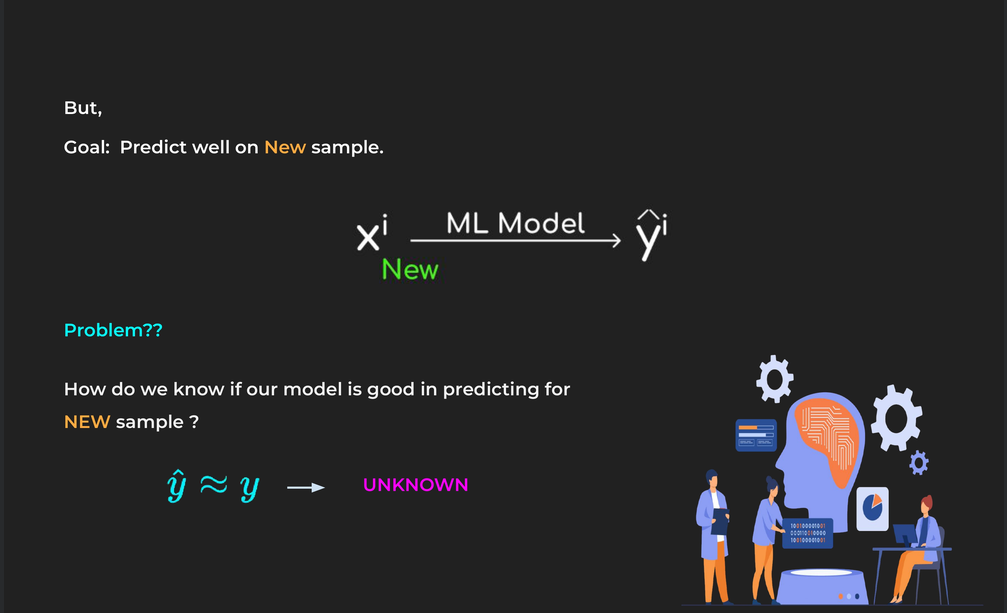

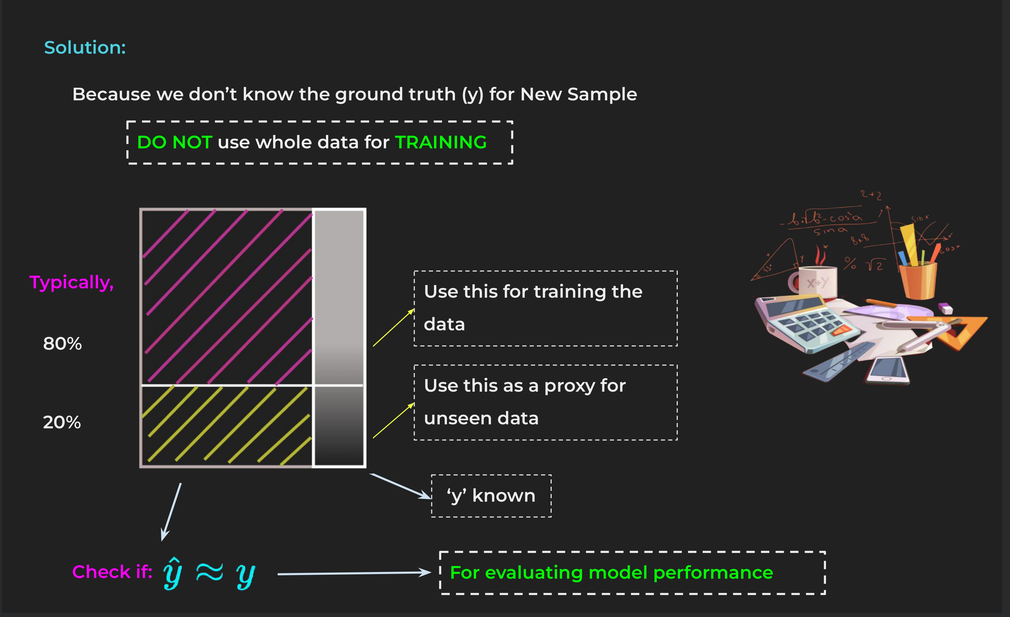
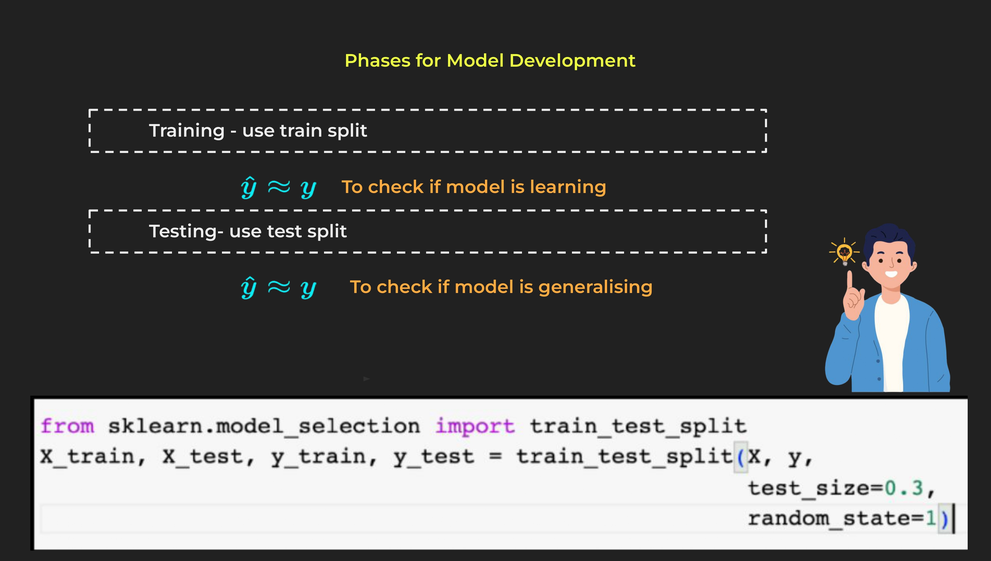

# 🎓 Training Data and Test Data — The Foundation of Machine Learning

---

# 🎯 Why Do We Split the Dataset?

The ultimate goal of Machine Learning is **not** to memorize the data we already have.

Instead, the goal is to make **accurate predictions on new, unseen data**.

To check whether a model has truly learned patterns instead of simply memorizing the dataset, we split the available data into two parts:

* **Training Data**
* **Test Data**

---

# 📚 Real-Life Analogy

Imagine you're preparing for a final exam.

You have **100 previous years' questions**.

Instead of studying all 100 and testing yourself on the same questions, you decide to:

* Study using **80 questions**
* Keep **20 questions hidden**

After completing your preparation, you attempt the 20 hidden questions.

If you perform well,

it means you **understood the concepts** rather than simply memorizing the questions.

Machine Learning follows the exact same idea.

---

# 📦 Original Dataset

Suppose we have a dataset of student information.

| Hours Studied | Attendance (%) | Passed |
| ------------- | -------------: | -----: |
| 2             |             60 |      0 |
| 5             |             80 |      1 |
| 7             |             90 |      1 |
| 3             |             70 |      0 |
| 6             |             85 |      1 |

Here,

* **Hours Studied**
* **Attendance**

are called **Features (X)**.

The column

```text
Passed
```

is called the **Target Variable (y)** because it is what we want to predict.

---

# ✂️ Splitting the Dataset

The complete dataset is divided into two parts.

```text
                Entire Dataset
                      │
                      ▼
      ┌────────────────────────────┐
      │                            │
      ▼                            ▼
 Training Dataset             Test Dataset
      80%                         20%
```

The exact ratio can vary depending on the problem.

Common splits include:

* 80% Training — 20% Testing
* 70% Training — 30% Testing
* 75% Training — 25% Testing

---

# 🎯 What is Training Data?

Training Data is the portion of the dataset used to **teach the machine learning model**.

The model studies this data and tries to discover relationships between the input features and the target.

For example,

the model may learn:

```text
More Hours Studied
        ↓
Higher Probability of Passing
```

or

```text
Higher Attendance
        ↓
Higher Probability of Passing
```

The model learns these patterns only from the **training dataset**.

---

# 🎯 What is Test Data?

The Test Data is **never shown to the model during learning**.

It is kept completely separate.

Once the model has finished learning from the training data, we use the test data to answer an important question:

> **"Can the model make accurate predictions on data it has never seen before?"**

If the answer is yes,

the model has successfully learned general patterns.

---

# 🤔 Why Can't We Train on the Entire Dataset?

Suppose you study all **100 previous years' questions**.

Now your teacher asks the **same 100 questions** in the exam.

You'll probably score:

```text
100%
```

But does that prove you understand the subject?

Not necessarily.

You may have simply memorized the answers.

Machine Learning has the same problem.

If we train and test on the same data,

the model may memorize the dataset instead of learning useful patterns.

---

# 🎯 The Purpose of the Test Dataset

The test dataset measures how well the model performs on **unseen data**.

It gives us an estimate of how the model is likely to perform in the real world.

Think of it as a **final exam** for the model.

---

# 📊 Example

Suppose we have **1000 records**.

```text
1000 Records
      │
      ▼
800 Records → Training
200 Records → Testing
```

The model learns using the **800 training records**.

Later,

it is evaluated using the **200 testing records** that it has never seen before.

---

# 📈 Training vs Testing

| Training Data                        | Test Data                                  |
| ------------------------------------ | ------------------------------------------ |
| Used to teach the model              | Used to evaluate the model                 |
| Usually 70–80% of the data           | Usually 20–30% of the data                 |
| Model learns patterns from this data | Model never sees this data during learning |
| Helps build the model                | Measures how well the model generalizes    |

---

# 🚀 Complete Workflow

```text
                  Original Dataset
                         │
                         ▼
                Split the Dataset
                         │
          ┌──────────────┴──────────────┐
          ▼                             ▼
   Training Dataset               Test Dataset
          │                             │
          ▼                             │
     Learn Patterns                     │
          │                             │
          └──────────────┐              │
                         ▼              ▼
                  Trained Model
                         │
                         ▼
          Predict on Test Dataset
                         │
                         ▼
          Compare Predictions with
             Actual Test Labels
                         │
                         ▼
             Measure Model Performance
```

---

# 📌 Key Takeaways

* The dataset is divided into **Training Data** and **Test Data**.
* The **Training Data** is used to teach the model.
* The **Test Data** is kept completely unseen during training.
* The purpose of the test dataset is to evaluate how well the model performs on new, unseen data.
* Splitting the dataset helps us determine whether the model has **learned patterns** or simply **memorized the training data**.

---

# 🚀 One-Line Summary

> **Training Data teaches the model, while Test Data evaluates how well the model can make predictions on unseen data, ensuring that it has learned general patterns rather than memorizing the dataset.**

---

# ⭐ Ultimate Intuition

> **Training Data:** *"Learn from these examples."*

> **Test Data:** *"Now prove you can solve problems you've never seen before."*

A good machine learning model is **not the one that remembers the training data**, but the one that **performs well on completely new data**.


# 🚨 Data Leakage — Why We Split the Dataset Before Preprocessing

---

# 🎯 What is Data Leakage?

Data Leakage occurs when **information from the test dataset accidentally becomes available during training**.

Remember,

the purpose of the **test dataset** is to simulate **completely unseen data**.

If the model gains any information from the test dataset before evaluation,

then the evaluation is no longer fair.

---

# 🤔 Why is Data Leakage a Problem?

The goal of Machine Learning is not to perform well on data we already know.

The goal is to perform well on **new, unseen data**.

If the model indirectly learns from the test dataset,

its evaluation score becomes **artificially high**.

The model appears better than it actually is.

---

# 📚 Real-Life Analogy

Imagine your teacher prepares:

* **100 practice questions**
* **20 final exam questions**

The correct process is:

```text
Study Practice Questions
          │
          ▼
Write Final Exam
          │
          ▼
Receive Your Score
```

Now imagine the teacher accidentally shows you the final exam before you begin studying.

```text
Teacher Shows Final Exam
          │
          ▼
You Study the Answers
          │
          ▼
Write the Same Exam
          │
          ▼
Score = 100%
```

Did you actually learn?

No.

You simply had access to information you shouldn't have seen.

This is exactly what happens during **Data Leakage**.

---

# 🎯 Machine Learning Equivalent

Suppose we have a dataset.

```text
Entire Dataset

1000 Rows
```

We divide it into

```text
800 Rows → Training Data

200 Rows → Test Data
```

The **Training Data** teaches the model.

The **Test Data** is used only to evaluate how well the model performs on unseen examples.

The test dataset should remain **completely hidden** until evaluation.

---

# ❌ Wrong Workflow

Suppose we perform scaling **before** splitting the dataset.

```text
Original Dataset
        │
        ▼
Scale Entire Dataset
        │
        ▼
Split into Train/Test
        │
        ▼
Train Model
```

At first glance,

this may seem harmless.

But something important happens behind the scenes.

---

# 🎯 Example Using Min-Max Scaling

Suppose our salary column is

| Salary |
| -----: |
|     20 |
|     30 |
|     40 |
|     50 |
|    100 |
|    120 |

Now imagine we apply Min-Max Scaling **before splitting**.

The scaler computes

```text
Minimum = 20

Maximum = 120
```

Notice something?

The values

```text
100

120
```

actually belong to the **test dataset**.

The scaler has already learned information from the test data.

This is **Data Leakage**.

---

# 🚨 Why Is This Bad?

The training process now knows:

```text
The maximum salary in the entire dataset is 120.
```

But during real-world deployment,

future data is unknown.

The training process should **never know information from future or unseen data**.

This makes the evaluation unrealistic.

---

# ❌ Data Leakage Example

```text
Entire Dataset

20
30
40
50
100
120
```

Scaler computes

```text
Minimum = 20

Maximum = 120
```

Later,

the data is split into

```text
Training

20
30
40
50
```

```text
Testing

100
120
```

Even though the model hasn't seen the test rows,

the scaler already has.

Information has leaked from the test dataset into training.

---

# ✅ Correct Workflow

Always split the dataset **before** performing any preprocessing.

```text
Entire Dataset
        │
        ▼
Split into Train/Test
        │
        ├──────────────┐
        ▼              ▼
Training Data      Test Data
```

Now,

all preprocessing steps learn **only from the training dataset**.

---

# 📊 Correct Scaling Example

Training salaries

```text
20

30

40

50
```

The scaler learns

```text
Minimum = 20

Maximum = 50
```

Notice

The scaler has **never seen**

```text
100

120
```

Now,

these same statistics are used to scale both datasets.

---

### Training Data

| Original | Scaled |
| -------- | -----: |
| 20       |   0.00 |
| 30       |   0.33 |
| 40       |   0.67 |
| 50       |   1.00 |

---

### Test Data

| Original | Scaled |
| -------- | -----: |
| 100      |   2.67 |
| 120      |   3.33 |

Many beginners think values greater than **1** are incorrect.

They are perfectly valid.

They simply indicate that the test values are larger than anything observed during training.

---

# 🎯 Why Split Before Encoding?

Suppose we have

| City    |
| ------- |
| Mumbai  |
| Delhi   |
| Pune    |
| Chennai |

Suppose

```text
Chennai
```

appears only in the test dataset.

If we encode the entire dataset before splitting,

the encoder already learns that

```text
Chennai
```

exists.

Again,

the training process has learned information from the test dataset.

This is another example of **Data Leakage**.

---

# 🎯 Why Split Before Imputation?

Suppose

Training Ages

```text
20

25

30
```

Test Ages

```text
100
```

If we calculate the mean using the entire dataset,

```text
20

25

30

100
```

Mean

```text
43.75
```

Now,

missing values in the training data are filled using information from the test dataset.

Again,

Data Leakage occurs.

---

# 🎯 Why Split Before Feature Selection?

Suppose one feature appears highly correlated with the target only because of the test data.

If feature selection is performed before splitting,

the training process benefits from information that should have remained hidden.

Again,

Data Leakage.

---

# 🚀 General Rule

Any preprocessing step that **learns something from the data** must learn **only from the training dataset**.

Examples include:

* Feature Scaling
* Label Encoding
* One-Hot Encoding
* Missing Value Imputation
* PCA
* Feature Selection
* Dimensionality Reduction
* Target Encoding

The correct sequence is always:

```text
Split First

↓

Learn from Training Data

↓

Apply Same Transformation to Training Data

↓

Apply Same Transformation to Test Data
```

---

# 📊 Wrong vs Correct Workflow

## ❌ Wrong

```text
Original Dataset
        │
        ▼
Scale / Encode / Impute
        │
        ▼
Split into Train/Test
        │
        ▼
Train Model
```

Information from the test dataset leaks into training.

---

## ✅ Correct

```text
Original Dataset
        │
        ▼
Split into Train/Test
        │
        ▼
Learn Preprocessing Rules
(Training Data Only)
        │
        ▼
Apply Same Rules to
Training and Test Data
        │
        ▼
Train the Model
        │
        ▼
Evaluate on Test Data
```

---

# 📌 Common Preprocessing Steps That Can Cause Data Leakage

| Preprocessing Step       | Should Be Learned From |
| ------------------------ | ---------------------- |
| Feature Scaling          | Training Data Only     |
| Standardization          | Training Data Only     |
| Min-Max Scaling          | Training Data Only     |
| Missing Value Imputation | Training Data Only     |
| Label Encoding           | Training Data Only     |
| One-Hot Encoding         | Training Data Only     |
| PCA                      | Training Data Only     |
| Feature Selection        | Training Data Only     |

---

# 📌 Key Takeaways

* The **test dataset** should represent completely unseen data.
* Any information learned from the test dataset before evaluation causes **Data Leakage**.
* Always perform **Train-Test Split before preprocessing**.
* Preprocessing methods that learn statistics (mean, minimum, maximum, categories, etc.) must learn only from the **training dataset**.
* The same learned transformations are then applied to both the training and test datasets.
* Preventing data leakage ensures that model evaluation accurately reflects real-world performance.

---

# 🚀 One-Line Summary

> **Data Leakage occurs when information from the test dataset influences the training process. To prevent this, always split the dataset first, learn all preprocessing transformations using only the training data, and then apply those same transformations to the test data.**

---

# ⭐ Ultimate Intuition

> **Training Data = Textbook**

> **Test Data = Final Exam**

If you look at the final exam while studying,

your exam score no longer reflects your true knowledge.

Similarly,

if the model learns anything from the test dataset before evaluation,

its performance no longer reflects how well it will perform on completely unseen data.

That is why **Train-Test Split must always happen before scaling, encoding, imputation, or any preprocessing step that learns information from the data.**


In [10]:
new_df=pd.read_csv("cars24-car-price-cleaned-new.csv")
new_df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


Now let's split the data.

We will divide it into 70:30 ratio:
- 70% for training,
- and 30% for testing.

In [12]:
from sklearn.model_selection import train_test_split
df_train,df_test=train_test_split(new_df,test_size=0.3,random_state=1)

# 📚 `train_test_split()` Explained

## Code

```python
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df1,
    test_size=0.3,
    random_state=1
)
```

---

## 🎯 Purpose

Splits the original dataset into:

* **Training Dataset** → Used to train the model.
* **Testing Dataset** → Used to evaluate the model on unseen data.

---

## 🔍 Parameter Breakdown

### `df1`

The original dataset that needs to be split.

---

### `test_size=0.3`

Specifies the proportion of data reserved for testing.

```
Training Data = 70%
Testing Data  = 30%
```

Example:

```
100 Rows

↓

70 Rows → Training

30 Rows → Testing
```

---

### `random_state=1`

Controls the randomness of the split.

* Ensures the dataset is shuffled the **same way every time**.
* Makes the results **reproducible**.

Without `random_state`, every execution may produce a different train-test split.

---

## 📦 Return Values

```python
df_train, df_test = train_test_split(...)
```

Returns two DataFrames:

* `df_train` → Training dataset
* `df_test` → Testing dataset

---

## 🔄 Workflow

```text
Original Dataset
        │
        ▼
Randomly Shuffle Rows
        │
        ▼
Split Dataset
        │
   ┌────┴────┐
   ▼         ▼
Train      Test
70%         30%
```

---

## 📝 One-Line Summary

> **`train_test_split()` randomly divides a dataset into training and testing sets, where `test_size` controls the split ratio and `random_state` ensures the split is reproducible.**


### Encoding the data

For encoding the train data,
- we can simply replace the value with category wise target mean



For encoding the test data,
- we'll have the get category wise mean from the train data and use that mean while encoding test data.

#### **Why can't we use value from test data?**

Remember that test data is unseen data,
- using the mean from test data will lead to data leakage
- All the params should be from train data.

In [13]:
make_category_mean=df_train.groupby("make")["selling_price"].mean()
model_category_mean=df_train.groupby("model")["selling_price"].mean()

In [14]:
df_train['make'] = df_train.groupby('make')['selling_price'].transform('mean')
df_train['model'] = df_train.groupby('model')['selling_price'].transform('mean')
df_test["make"]=df_test["make"].map(make_category_mean)
df_test["model"]=df_test["model"].map(model_category_mean)

# 🎯 Target Encoding (Mean Encoding)

Target Encoding replaces each category with the **average value of the target variable** for that category.

In this example, the target variable is:

```text
selling_price
```

---

# 📌 Step 1: Calculate Category-wise Mean

```python
make_category_wise_mean = df_train.groupby('make')['selling_price'].mean()

model_category_wise_mean = df_train.groupby('model')['selling_price'].mean()
```

### What does this do?

* Groups the training data by each category.
* Computes the **average selling price** for every category.

### Example

| make   | selling_price |
| ------ | ------------: |
| Honda  |        500000 |
| Honda  |        450000 |
| Toyota |        900000 |
| Toyota |       1800000 |
| Honda  |        550000 |

After grouping:

| make   | Mean Selling Price |
| ------ | -----------------: |
| Honda  |             500000 |
| Toyota |            1350000 |

---

# 📌 Step 2: Encode the Training Data

```python
df_train['make'] = df_train.groupby('make')['selling_price'].transform('mean')

df_train['model'] = df_train.groupby('model')['selling_price'].transform('mean')
```

### Why `transform('mean')`?

`groupby().mean()` returns **one value per category**, whereas `transform('mean')` returns **one value for every row**.

It replaces each category with its corresponding mean.

### Before

| make   | selling_price |
| ------ | ------------: |
| Honda  |        500000 |
| Honda  |        450000 |
| Toyota |        900000 |

### After

| make    | selling_price |
| ------- | ------------: |
| 500000  |        500000 |
| 500000  |        450000 |
| 1350000 |        900000 |

---

# 📌 Step 3: Encode the Test Data

```python
df_test['make'] = df_test['make'].map(make_category_wise_mean)

df_test['model'] = df_test['model'].map(model_category_wise_mean)
```

### Why `map()`?

The test dataset **must not calculate its own category means**.

Instead, it uses the means learned from the **training dataset**.

Example

Training Mean Mapping

```text
Honda  → 500000
Toyota → 1350000
Ford   → 800000
```

Test Data

| make   |
| ------ |
| Honda  |
| Ford   |
| Toyota |

After `map()`

|    make |
| ------: |
|  500000 |
|  800000 |
| 1350000 |

---

# 🚨 Why Not Compute Means on the Test Data?

If we calculate category means using the test dataset,

the model indirectly learns information from the test data.

This is called **Data Leakage**.

To avoid this:

* ✅ Compute category means **only on the training data**.
* ✅ Apply those learned means to the test data using `map()`.
* ❌ Never compute category means from the test dataset.

---

# 🔄 Complete Workflow

```text
                  Training Data
                        │
                        ▼
      Group by Category (make/model)
                        │
                        ▼
        Compute Mean Selling Price
                        │
                        ▼
 Replace Categories using transform('mean')
                        │
                        ▼
          Train Machine Learning Model
────────────────────────────────────────────
                        │
                        ▼
                   Test Data
                        │
                        ▼
      Replace Categories using map()
                        │
                        ▼
             Encoded Test Data
```

---

# 📌 Key Takeaways

* **Target Encoding** replaces categories with the **mean of the target variable**.
* Category means are calculated **only from the training dataset**.
* `transform('mean')` replaces every training row with its category mean.
* `map()` applies the same learned mapping to the test dataset.
* Using the test dataset to compute category means leads to **Data Leakage**.

---

# 🚀 One-Line Summary

> **Target Encoding replaces categorical values with their average target value, where the mapping is learned from the training data and applied to the test data using `map()` to prevent data leakage.**


There is a chance that
- a model of car is present in test dataset but not in train dataset

#### **How do we handle this?**

=> We encode it with the global mean of  the train data.

Let's check if there are any NaNs after encoding

In [16]:
df_test.isna().sum()

selling_price         0
km_driven             0
mileage               0
engine                0
max_power             0
age                   0
make                  5
model               468
Individual            0
Trustmark Dealer      0
Diesel                0
Electric              0
LPG                   0
Petrol                0
Manual                0
5                     0
>5                    0
dtype: int64

In [19]:
global_mean=df_train["selling_price"].mean()
df_test.fillna(global_mean)


,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
14690,1.35,70000,17.00,1086.0,5.0,14.0,5.437345,6.566364,1,0,0,0,0,0,1,1,0
134,4.15,58000,25.20,1248.0,74.0,8.0,4.683960,4.699310,0,0,1,0,0,0,1,1,0
4982,4.90,50000,25.32,1198.0,77.0,6.0,7.320377,6.000000,0,0,1,0,0,0,1,0,1
11940,3.31,72000,16.80,1497.0,118.0,13.0,5.949517,3.530000,0,0,0,0,0,1,0,1,0
10861,5.80,70000,26.59,1248.0,74.0,8.0,4.683960,5.261472,1,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10638,6.50,54000,25.80,1498.0,98.6,5.0,5.949517,4.120000,0,0,1,0,0,0,1,1,0
74,4.25,58000,14.53,1794.0,138.1,14.0,10.442393,8.004444,0,0,0,0,0,1,0,1,0
18009,2.25,50000,18.00,995.0,62.0,11.0,2.601774,1.278889,0,0,0,0,0,1,1,1,0
19144,4.00,80000,16.80,1497.0,118.0,13.0,5.949517,3.225000,1,0,0,0,0,1,0,1,0


### Scaling

In [21]:
scaler=MinMaxScaler()
df_train=pd.DataFrame(scaler.fit_transform(df_train),columns=df_train.columns)
df_test=pd.DataFrame(scaler.transform(df_test),columns=df_test.columns)

# 📏 Scaling Training and Test Data using `MinMaxScaler`

---

# 🎯 Goal

Feature Scaling transforms numerical features to a **common scale** so that no feature dominates another because of its larger magnitude.

In this example, we use **Min-Max Scaling**, which scales every feature to the range **0 to 1**.

---

# 💻 Code

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_train = pd.DataFrame(
    scaler.fit_transform(df_train),
    columns=df.columns
)

df_test = pd.DataFrame(
    scaler.transform(df_test),
    columns=df.columns
)
```

---

# 📌 Step 1: Create the Scaler

```python
scaler = MinMaxScaler()
```

### What happens?

A **MinMaxScaler** object is created.

At this stage, the scaler has **not learned anything** about the data.

Think of it as creating an empty calculator that is waiting for data.

---

# 📌 Step 2: Scale the Training Data

```python
df_train = pd.DataFrame(
    scaler.fit_transform(df_train),
    columns=df.columns
)
```

This line performs **two operations**.

---

## Part A — `fit()`

The scaler first **learns** the training data.

For every feature, it calculates:

* Minimum Value
* Maximum Value

### Example

| Age |
| --: |
|  20 |
|  30 |
|  40 |
|  50 |

The scaler learns

```text
Minimum = 20

Maximum = 50
```

It stores these values internally.

No scaling happens yet.

---

## Part B — `transform()`

Now the scaler uses the learned values to scale every feature.

Formula

[
x_{scaled}
==========

\frac{x-x_{min}}
{x_{max}-x_{min}}
]

Example

Original Age

| Age |
| --: |
|  20 |
|  30 |
|  40 |
|  50 |

Scaled Age

|  Age |
| ---: |
| 0.00 |
| 0.33 |
| 0.67 |
| 1.00 |

Every value is now between **0** and **1**.

---

## Why `fit_transform()`?

Instead of writing

```python
scaler.fit(df_train)

df_train = scaler.transform(df_train)
```

Scikit-Learn provides a shortcut:

```python
scaler.fit_transform(df_train)
```

It simply means:

```text
Learn

↓

Immediately Apply
```

---

# 📌 Step 3: Convert Back to a DataFrame

`fit_transform()` returns a **NumPy array**.

Since NumPy arrays don't contain column names,

we convert it back into a DataFrame.

```python
pd.DataFrame(
    scaler.fit_transform(df_train),
    columns=df.columns
)
```

This preserves:

* ✅ Column Names
* ✅ Tabular Structure

---

# 📌 Step 4: Scale the Test Data

```python
df_test = pd.DataFrame(
    scaler.transform(df_test),
    columns=df.columns
)
```

Notice that we use

```python
transform()
```

and **not**

```python
fit_transform()
```

Why?

Because the scaler has already learned the minimum and maximum values from the **training dataset**.

The test dataset should only be transformed using the **same learned values**.

---

# 🚨 Why Not Use `fit_transform()` on the Test Data?

Suppose

Training Data

```text
Age

20
30
40
50
```

The scaler learns

```text
Minimum = 20

Maximum = 50
```

Now suppose the Test Data is

```text
Age

60
80
```

If we write

```python
scaler.fit_transform(df_test)
```

the scaler learns

```text
Minimum = 60

Maximum = 80
```

Now,

* Training data is scaled using **20–50**
* Test data is scaled using **60–80**

The two datasets are on **different scales**.

Even worse,

the preprocessing step has learned information from the test dataset.

This is called **Data Leakage**.

---

# ✅ Correct Approach

Always learn the scaling parameters from the **training data only**.

Then use those same parameters to scale the test data.

```text
Training Data
      │
      ▼
fit()
(Learn Min & Max)
      │
      ▼
transform()
(Scale Training Data)
──────────────────────────
      │
      ▼
Test Data
      │
      ▼
transform()
(Use SAME Min & Max)
```

---

# 📊 Workflow

```text
Original Dataset
        │
        ▼
Split into Train/Test
        │
        ▼
Create MinMaxScaler
        │
        ▼
fit_transform() on Training Data
(Learn + Scale)
        │
        ▼
transform() on Test Data
(Use SAME Learned Values)
        │
        ▼
Train Machine Learning Model
```

---

# 📌 Key Takeaways

* `MinMaxScaler()` creates the scaler object.
* `fit()` learns the **minimum** and **maximum** values from the training data.
* `transform()` scales the data using those learned values.
* `fit_transform()` combines both operations.
* Use **`fit_transform()` only on the training dataset**.
* Use **`transform()` only on the test dataset**.
* Never fit the scaler on the test dataset, as it causes **Data Leakage**.

---

# 🚀 One-Line Summary

> **Learn the scaling parameters (minimum and maximum) from the training data using `fit_transform()`, then use those same parameters to scale the test data with `transform()` to ensure consistent preprocessing and prevent data leakage.**

---

# ⭐ Ultimate Intuition

Imagine a teacher creating a grading scale.

* **Training Data:** The teacher decides the grading scale by looking at previous students' marks (**fit**).
* **Training Data:** The teacher converts those marks into percentages (**transform**).
* **Test Data:** New students are graded using the **same grading scale**, not a new one.

Similarly,

* **`fit_transform()`** = Learn + Apply (Training Data)
* **`transform()`** = Apply Only (Test Data)


From our data:
- The output data, `y` is the column `selling_price`
- Remaining columns are the input data, `X`

In [22]:
y_train=df_train["selling_price"]
x_train=df_train.drop("selling_price",axis=1)

In [23]:
y_test=df_test["selling_price"]
x_test=df_test.drop("selling_price",axis=1)

# 🎯 Separating Features (X) and Target (y)

Before training a Machine Learning model, we must separate the dataset into:

* **Features (X)** → Input variables used for prediction.
* **Target (y)** → Output variable that the model needs to predict.

---

# 💻 Code

```python
# Training Data
y_train = df_train['selling_price']
X_train = df_train.drop('selling_price', axis=1)

# Test Data
y_test = df_test['selling_price']
X_test = df_test.drop('selling_price', axis=1)
```

---

# 📌 Step 1: Create the Target Variable (`y_train`)

```python
y_train = df_train['selling_price']
```

### What happens?

This extracts the **target column** from the training dataset.

The target is the value that the Machine Learning model is trying to predict.

### Example

Original Training Data

| Make    | Year | KM Driven | Selling Price |
| ------- | ---: | --------: | ------------: |
| Honda   | 2020 |     20000 |        500000 |
| Toyota  | 2019 |     35000 |        700000 |
| Hyundai | 2021 |     15000 |        600000 |

After

```python
y_train = df_train['selling_price']
```

`y_train`

| Selling Price |
| ------------: |
|        500000 |
|        700000 |
|        600000 |

---

# 📌 Step 2: Create the Feature Matrix (`X_train`)

```python
X_train = df_train.drop('selling_price', axis=1)
```

### What happens?

The `selling_price` column is removed from the dataset.

The remaining columns become the **features (inputs)**.

### Before

| Make   | Year | KM Driven | Selling Price |
| ------ | ---: | --------: | ------------: |
| Honda  | 2020 |     20000 |        500000 |
| Toyota | 2019 |     35000 |        700000 |

### After

| Make   | Year | KM Driven |
| ------ | ---: | --------: |
| Honda  | 2020 |     20000 |
| Toyota | 2019 |     35000 |

These features are used by the model to predict the selling price.

---

# 📌 Why `axis=1`?

```python
.drop('selling_price', axis=1)
```

In Pandas,

* `axis=0` → Operates on **rows**
* `axis=1` → Operates on **columns**

Since `selling_price` is a **column**, we use:

```python
axis=1
```

---

# 📌 Step 3: Check the Shapes

```python
y_train.shape, X_train.shape
```

Output

```python
((13874,), (13874, 16))
```

### Understanding the Output

### `y_train.shape`

```text
(13874,)
```

Means:

* **13,874 target values**
* A one-dimensional **Series**

---

### `X_train.shape`

```text
(13874, 16)
```

Means:

* **13,874 rows (samples)**
* **16 feature columns**

Each training example has:

```text
16 Features
      ↓
Predict
      ↓
1 Target Value
```

---

# 📌 Step 4: Repeat for Test Data

```python
y_test = df_test['selling_price']

X_test = df_test.drop('selling_price', axis=1)
```

The same process is performed on the test dataset.

* `X_test` → Features used for prediction.
* `y_test` → Actual values used for evaluation.

---

# 📊 Train vs Test

| Dataset      | Features (X) | Target (y) | Purpose                    |
| ------------ | ------------ | ---------- | -------------------------- |
| **Training** | `X_train`    | `y_train`  | Used to train the model    |
| **Testing**  | `X_test`     | `y_test`   | Used to evaluate the model |

---

# 🎯 Why Do We Separate X and y?

The model should **learn** how the features relate to the target.

Example:

| Year | KM Driven | Brand | Selling Price |
| ---- | --------: | ----- | ------------: |
| 2020 |     20000 | Honda |        500000 |

The model is given only:

```text
Year
KM Driven
Brand
```

These are the **Features (X)**.

The correct answer is:

```text
Selling Price = ₹5,00,000
```

This is the **Target (y)**.

The model learns the relationship:

```text
Features (X)
      │
      ▼
Machine Learning Model
      │
      ▼
Target (y)
```

If we also provide the target as an input, the model already knows the answer and has nothing to learn.

---

# 🔄 Complete Workflow

```text
Original Dataset
        │
        ▼
Train-Test Split
        │
        ▼
Encoding
        │
        ▼
Scaling
        │
        ▼
Separate Features (X) and Target (y)
        │
   ┌────┴────┐
   ▼         ▼
X_train   y_train
(Features) (Target)
        │
        ▼
Train Machine Learning Model
─────────────────────────────────
        │
        ▼
X_test    y_test
(Features) (Target)
        │
        ▼
Evaluate Model Performance
```

---

# 📌 Key Takeaways

* **Features (X)** are the input variables used for prediction.
* **Target (y)** is the output variable the model needs to predict.
* `drop('selling_price', axis=1)` removes the target column from the feature set.
* `y_train` and `y_test` contain only the target values.
* `X_train` and `X_test` contain only the feature columns.
* The model learns using **X_train → y_train** and is evaluated using **X_test → y_test**.

---

# 🚀 One-Line Summary

> **Before training a Machine Learning model, the dataset is separated into Features (X) and Target (y), where X contains the input variables used for prediction and y contains the output variable that the model is trained to predict.**

---

# ⭐ Ultimate Intuition

> **Features (X)** = *The clues or information given to the model.*

> **Target (y)** = *The correct answer the model is trying to learn.*

The model's job is to learn the relationship:

```text
Features (X)
      │
      ▼
Machine Learning Model
      │
      ▼
Target (y)
```


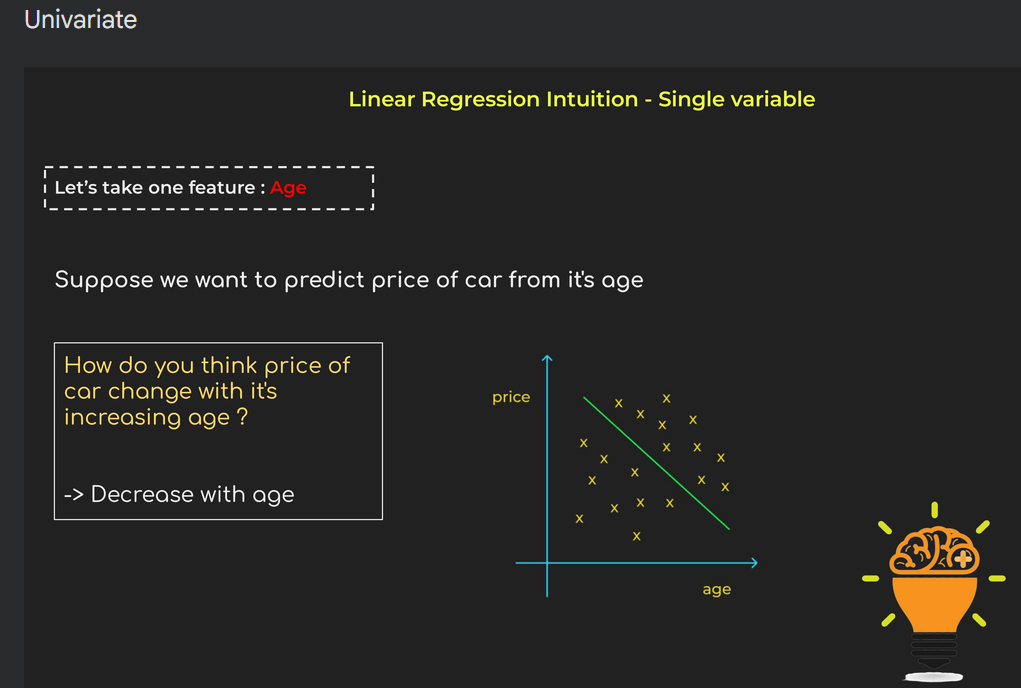
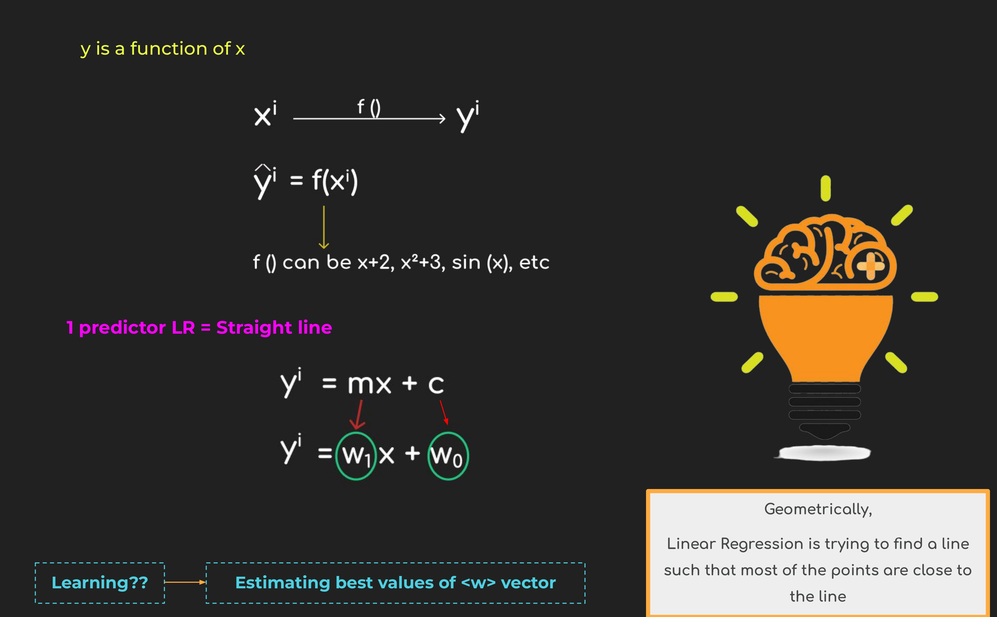

# 📈 Linear Regression — Core Intuition

---

# 🎯 The Goal of Machine Learning

The primary objective of Machine Learning is to learn the relationship between the **input features (X)** and the **output (Y)**.

Mathematically,

[
y = f(x)
]

where:

* **x** → Input Features (Independent Variables)
* **y** → Output (Dependent Variable)
* **f(x)** → Unknown function that maps the inputs to the output

---

# 📦 General Machine Learning Model

```text
Input (X)
    │
    ▼
 Unknown Function f(x)
    │
    ▼
Output (Y)
```

Examples:

```text
House Area
      │
      ▼
   Unknown Function
      │
      ▼
 House Price
```

```text
Car Age
Mileage
Brand
      │
      ▼
 Unknown Function
      │
      ▼
Selling Price
```

The challenge is:

> **We don't know what the function `f(x)` is.**

Our goal is to learn it from the available data.

---

# 🎯 What is Learning?

One of the most important ideas in Machine Learning is:

> **Learning simply means finding the best model parameters.**

For Linear Regression,

these parameters are called **Weights**.

The slide summarizes this as:

```text
Learning
     │
     ▼
Estimating the Best Values of the Weight Vector (W)
```

Machine Learning is essentially an optimization problem where we search for the best parameter values that produce the most accurate predictions.

---

# 📌 Single Predictor Linear Regression

Suppose there is only **one input feature**.

Example:

```text
x = House Area

y = House Price
```

Linear Regression assumes that the relationship between x and y is a **straight line**.

Mathematically,

[
y = mx + c
]

where:

* **m** = Slope
* **c** = Intercept

---

# 📌 Machine Learning Notation

In Machine Learning, the equation is written as:

[
\hat{y}=w_1x+w_0
]

where:

* **w₁** = Weight (Slope)
* **w₀** = Bias (Intercept)

Thus,

```text
m  →  w₁

c  →  w₀
```

Both equations represent exactly the same straight line.

---

# 📌 Understanding the Weights

## 🟢 Weight (w₁)

The weight determines **how much the prediction changes when the input changes**.

Example:

[
\hat y = 10x + 5
]

If **x increases by 1**,

the prediction increases by **10**.

---

## 🟢 Bias (w₀)

The bias determines the starting point of the line.

Example:

[
\hat y = 10x + 5
]

When

[
x=0
]

the prediction becomes

[
\hat y=5
]

Therefore,

```text
w₀ → Starting Value

w₁ → Rate of Change
```

---

# 📌 Why Do We Write ŷ Instead of y?

Linear Regression predicts values.

Therefore,

we distinguish between:

* **y** → Actual Value
* **ŷ** → Predicted Value

Example:

```text
Actual Selling Price

₹8,50,000
```

```text
Predicted Selling Price

₹8,20,000
```

Here,

```text
y  = Actual Value

ŷ = Predicted Value
```

---

# 📌 What Does the Model Learn?

Initially,

the model does **not know** the values of:

```text
w₀ = ?

w₁ = ?
```

It starts with random values.

Example:

```text
w₀ = 1.5

w₁ = 0.8
```

Using these values,

the model makes predictions.

If the predictions are inaccurate,

the weights are updated.

This process continues until the prediction error becomes as small as possible.

---

# 📌 Geometrical Interpretation

Imagine plotting all the training data on a graph.

```text
Price
 ↑

80 |          ●
70 |
60 |       ●
50 |    ●
40 | ●
30 |
   +--------------------→ Area
```

Linear Regression tries to find the **best-fit straight line**.

```text
Price
 ↑

80 |          ●
70 |         /
60 |      ● /
50 |    ●  /
40 | ●    /
30 |
   +--------------------→ Area
```

The objective is:

> **Find the line that passes as close as possible to most of the data points.**

---

# 📌 What Happens During Training?

Training is an iterative process.

```text
Initialize Random Weights
          │
          ▼
Make Predictions
          │
          ▼
Calculate Prediction Error
          │
          ▼
Update Weights
          │
          ▼
Repeat Until Error is Minimum
```

Eventually,

the model finds the best values of:

```text
w₀

w₁
```

These values define the final regression line.

---

# 📊 Example

Training Data

| Area | Price |
| ---: | ----: |
|    1 |     3 |
|    2 |     5 |
|    3 |     7 |
|    4 |     9 |

After training,

the model learns:

[
\hat y=2x+1
]

Predictions

| Area | Predicted Price |
| ---: | --------------: |
|    1 |               3 |
|    2 |               5 |
|    3 |               7 |
|    4 |               9 |

The learned parameters are:

```text
w₁ = 2

w₀ = 1
```

---

# 🔄 Complete Workflow

```text
Training Data
      │
      ▼
Initialize Random Weights
      │
      ▼
Predict Output (ŷ)
      │
      ▼
Compare with Actual Output (y)
      │
      ▼
Calculate Error
      │
      ▼
Update Weights (w₀, w₁)
      │
      ▼
Repeat Until Error is Minimum
      │
      ▼
Final Regression Line
```

---

# 📌 Key Takeaways

* Linear Regression assumes a **linear relationship** between input and output.
* The prediction equation is:

[
\hat y=w_1x+w_0
]

* **w₁** controls the slope of the line.
* **w₀** controls the intercept (starting point).
* The model learns by finding the best values of **w₀** and **w₁**.
* The objective is to minimize the prediction error.
* Geometrically, Linear Regression tries to find the **best-fit straight line** through the data.

---

# 🚀 One-Line Summary

> **Linear Regression learns the best values of the weights (w₀ and w₁) so that the predicted values (ŷ) are as close as possible to the actual values (y), resulting in the best-fit straight line through the data.**

---

# ⭐ Ultimate Intuition

> **Linear Regression is nothing more than searching for the best straight line.**

That search is equivalent to finding the best values of:

```text
w₀ (Bias)

and

w₁ (Weight)
```

Once these values are learned,

the model can predict the output for any new input using:

[
\boxed{\hat y=w_1x+w_0}
]


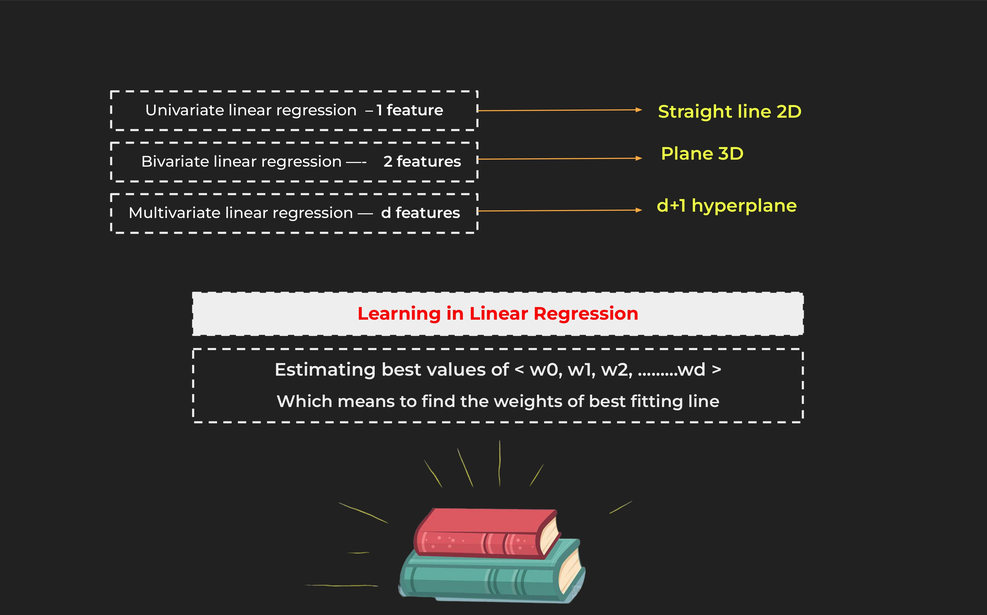

In [ ]:
x1_train=x_train[["model"]]
x1_test=x_test[["model"]]

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x1_train,y_train)
display(model.coef_,model.intercept_)
y_hat=model.predict()
display(y_hat)

array([0.99878656])

np.float64(0.0012134449702719818)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values